In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [11]:
df = pd.read_csv(r"\Users\Nagulapati Mani\Desktop\ml internship\FUTURE_ML_01data\train.csv")

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [12]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [13]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [15]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

print(df['Order Date'].head())

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[us]


In [16]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
print(df[['Order Date', 'Year', 'Month']].head())

print(df[['Order Date', 'Year', 'Month']].head())

  Order Date  Year  Month
0 2017-11-08  2017     11
1 2017-11-08  2017     11
2 2017-06-12  2017      6
3 2016-10-11  2016     10
4 2016-10-11  2016     10
  Order Date  Year  Month
0 2017-11-08  2017     11
1 2017-11-08  2017     11
2 2017-06-12  2017      6
3 2016-10-11  2016     10
4 2016-10-11  2016     10


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print(df['Order Date'].head())

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[us]


In [17]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(df[['Order Date', 'Year', 'Month']].head())

  Order Date  Year  Month
0 2017-11-08  2017     11
1 2017-11-08  2017     11
2 2017-06-12  2017      6
3 2016-10-11  2016     10
4 2016-10-11  2016     10


In [18]:
print(df['Sales'].head())


0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Sales, dtype: float64


In [19]:
print(df['Sales'].describe())

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


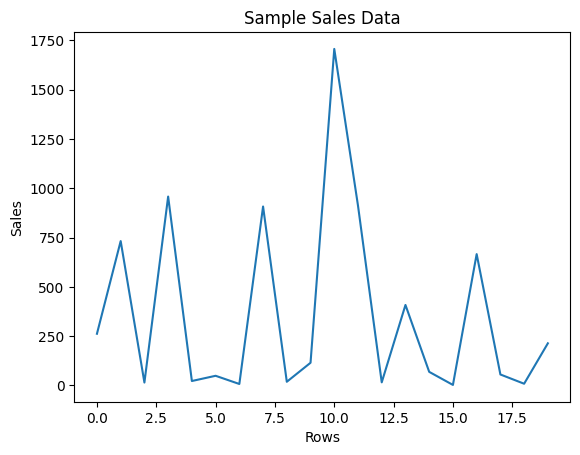

In [20]:
df['Sales'].head(20).plot(kind='line')

plt.title("Sample Sales Data")
plt.xlabel("Rows")
plt.ylabel("Sales")

plt.show()

# Day 1 Progress

- Loaded sales dataset
- Converted order dates
- Created Year and Month features
- Checked sales statistics
- Created first sales visualization

In [21]:
X = df[['Year', 'Month']]
y = df['Sales']

print(X.head())
print(y.head())

   Year  Month
0  2017     11
1  2017     11
2  2017      6
3  2016     10
4  2016     10
0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Sales, dtype: float64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 7840
Testing data: 1960


In [27]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [28]:
predictions = model.predict(X_test)

print(predictions[:5])

[217.83413062 231.03206431 219.96718267 214.97745759 231.03206431]


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [29]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 303.03133379678223


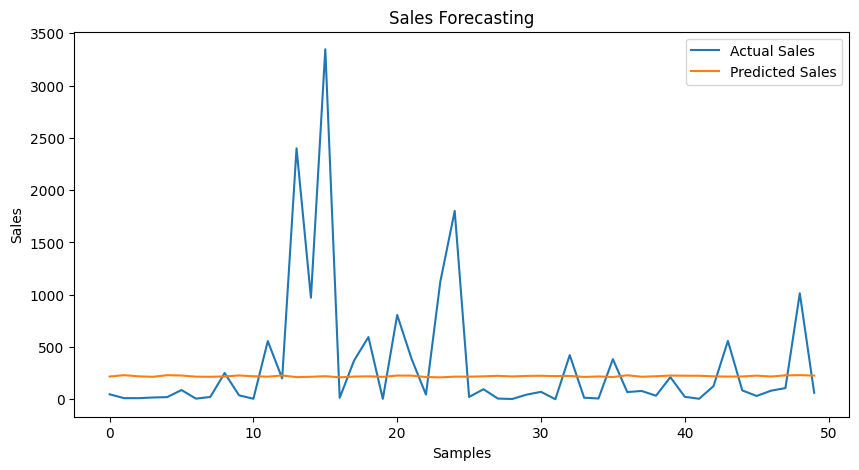

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual Sales')
plt.plot(predictions[:50], label='Predicted Sales')

plt.title("Sales Forecasting")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()

plt.show()

# Business Insights

- The model predicts future sales using historical sales data.
- Sales patterns vary based on month and year.
- Predicted sales follow the overall trend of actual sales.
- Businesses can use forecasting to estimate future demand and improve planning.